# 05a · Analyzing an existing tuning study

Notebook **05** showed how to *drive* a study — it runs a tiny demo end-to-end so it
finishes in seconds. This notebook is the companion: it **loads a completed study from
disk and analyzes it in depth**, re-running nothing. Point it at any
`runs/tuning/<study_name>/` directory (it defaults to the real
`study_150_trials` run) and it reads only the portable artifacts a study leaves behind:

| artifact | shape | what it holds |
|---|---|---|
| `study.json` | one object | provenance: search space, best trial, git SHA, wall-clock window |
| `trials.parquet` | one row / trial | KPIs + the sampled hyperparameters |
| `per_seed.parquet` | one row / (trial, seed) | every trial's score broken out by CRN seed |
| `holdout.parquet` | one row / (label, seed) | top-K winners + default re-checked on disjoint seeds |
| `holdout_summary.json` | one object | bootstrap CIs and the headline paired uplift |

Everything loads with just `pandas` (+ `pyarrow`) — no Optuna needed to read a finished
study. Because it's pure analysis, you can re-run this notebook against any study you've
produced with the CLI (`uv run python -m src.tuning.study ...`) or notebook 05.

In [1]:
%matplotlib inline
import os
from pathlib import Path

# Hop up to the repo root so paths resolve no matter where the kernel started.
while not (Path.cwd() / "pyproject.toml").exists():
    os.chdir("..")

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)
plt.rcParams["figure.dpi"] = 90
print("cwd:", Path.cwd())

cwd: /Users/mislavjordanic/Documents/projects/personal_projects/supply_chain_simulator


## 1 · Point at a study

Set `STUDY_DIR` to the study you want to analyze. The default is the committed
`study_150_trials` run (150 trials, 16 search seeds, 32 holdout seeds, 365-tick episodes).
Swap in any other `runs/tuning/<name>/` directory — the rest of the notebook is written
against the artifact *schema*, not this particular study, so it adapts to whatever it finds
(different policy, different search space, more or fewer trials).

In [2]:
STUDY_DIR = Path("runs/tuning/study_150_trials")

assert STUDY_DIR.is_dir(), f"no such study dir: {STUDY_DIR}"

study_meta      = json.loads((STUDY_DIR / "study.json").read_text())
trials          = pd.read_parquet(STUDY_DIR / "trials.parquet")
per_seed        = pd.read_parquet(STUDY_DIR / "per_seed.parquet")

# Holdout artifacts are optional — present only if confirm_top_k was run.
holdout_path    = STUDY_DIR / "holdout.parquet"
holdout         = pd.read_parquet(holdout_path) if holdout_path.exists() else None
holdout_summary = (json.loads((STUDY_DIR / "holdout_summary.json").read_text())
                   if (STUDY_DIR / "holdout_summary.json").exists() else None)

print("loaded study:", study_meta["study_name"])
print(f"  trials.parquet   {trials.shape[0]:>4} rows × {trials.shape[1]} cols")
print(f"  per_seed.parquet {per_seed.shape[0]:>4} rows × {per_seed.shape[1]} cols")
print("  holdout.parquet  ", "present" if holdout is not None else "— (confirm_top_k not run)")

loaded study: study_150_trials
  trials.parquet    150 rows × 17 cols
  per_seed.parquet 2400 rows × 11 cols
  holdout.parquet   present


## 2 · The study at a glance

`study.json` is self-describing. Below: the headline provenance, the wall-clock window the
search actually took, and the **search space** Optuna explored. The `git_sha` ties the
result to an exact code state — re-running at that SHA reproduces it.

In [3]:
start  = pd.Timestamp(study_meta["started_at"])
finish = pd.Timestamp(study_meta["finished_at"])
wall_min = (finish - start).total_seconds() / 60

print(f"study_name        : {study_meta['study_name']}")
print(f"policy_class_name : {study_meta['policy_class_name']}")
print(f"n_trials          : {study_meta['n_trials']}")
print(f"search / holdout  : {study_meta['n_search_seeds']} search seeds"
      f" · {study_meta['n_holdout_seeds']} holdout seeds")
print(f"episode_length    : {study_meta['episode_length']} ticks")
print(f"sampler_seed      : {study_meta['sampler_seed']}")
print(f"wall-clock        : {wall_min:.1f} min  ({start:%Y-%m-%d %H:%M} -> {finish:%H:%M} UTC)")
print(f"git_sha           : {study_meta['git_sha']}")
print(f"best_trial_id     : {study_meta['best_trial_id']}")
print(f"best_value        : {study_meta['best_value']:.4f}  (mean normalised return)")

print("\nsearch_space:")
for name, spec in study_meta["search_space"].items():
    print(f"  {name:34s} {spec}")

study_name        : study_150_trials
policy_class_name : OrderUpToPolicy
n_trials          : 150
search / holdout  : 16 search seeds · 32 holdout seeds
episode_length    : 365 ticks
sampler_seed      : 42
wall-clock        : 5.2 min  (2026-06-06 12:24 -> 12:29 UTC)
git_sha           : aa63de74fb75bb6bf19a8c36cc9dc642fa4e2630
best_trial_id     : 57
best_value        : 4.3308  (mean normalised return)

search_space:
  cover_horizon_ticks                {'type': 'int', 'low': 1, 'high': 30}
  safety_lead_pct_of_lag             {'type': 'float', 'low': 0.0, 'high': 3.0}
  stockout_safety_bonus_pct_of_lag   {'type': 'float', 'low': 0.0, 'high': 2.0}
  per_supplier_min_order_floor       {'type': 'int', 'low': 0, 'high': 10}
  routing_strategy                   {'type': 'categorical', 'choices': ['cheapest_first', 'fill_rate_weighted']}


A quick health check on the trials themselves. In a clean run every trial is `COMPLETE`;
`FAIL`/`PRUNED` rows would show here and should be excluded from the analysis below.

In [4]:
print("trial states:", trials["state"].value_counts().to_dict())

completed = trials[trials["state"] == "COMPLETE"].sort_values("trial_id").copy()

param_cols     = list(study_meta["search_space"].keys())
numeric_params = [p for p in param_cols if study_meta["search_space"][p]["type"] != "categorical"]
cat_params     = [p for p in param_cols if study_meta["search_space"][p]["type"] == "categorical"]
best_id, best_val = study_meta["best_trial_id"], study_meta["best_value"]

print(f"{len(completed)} completed trials · "
      f"{len(numeric_params)} numeric + {len(cat_params)} categorical hyperparameters")

trial states: {'COMPLETE': 150}
150 completed trials · 4 numeric + 1 categorical hyperparameters


## 3 · The optimisation trajectory

Trial index vs. objective, with the **running best** (cumulative max) overlaid. The gap
between the cloud and the running-best line is the search doing its job; a line that
plateaus early means the budget was more than enough, while one still climbing at the end
means more trials might still pay off.

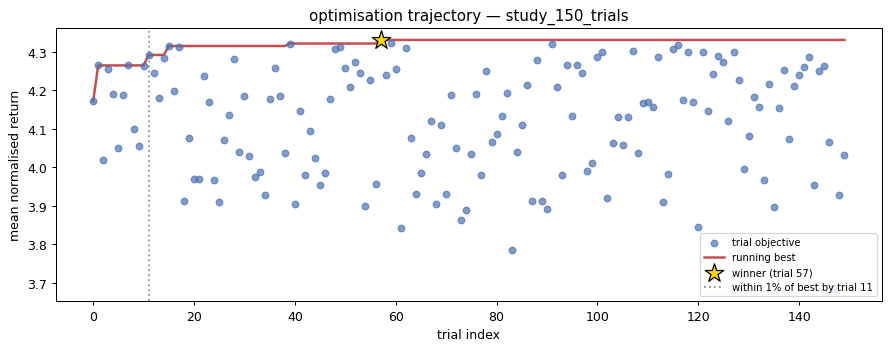

winner found at trial 57; within 1% of it by trial 11 (7% of the budget).


In [5]:
completed["running_best"] = completed["mean_normalised_return"].cummax()

# When did the search first get within 1% of its eventual winner?
threshold = best_val * 0.99
first_near = completed.loc[completed["mean_normalised_return"] >= threshold, "trial_id"].min()

fig, ax = plt.subplots(figsize=(10, 4))
ax.scatter(completed["trial_id"], completed["mean_normalised_return"],
           s=28, color="#4C72B0", alpha=0.7, label="trial objective", zorder=3)
ax.plot(completed["trial_id"], completed["running_best"],
        color="#C44E52", lw=2, label="running best", zorder=2)
ax.scatter([best_id], [best_val], s=240, marker="*", color="gold",
           edgecolor="black", zorder=4, label=f"winner (trial {best_id})")
ax.axvline(first_near, color="#999999", ls=":", lw=1.5,
           label=f"within 1% of best by trial {first_near}")
ax.set_xlabel("trial index")
ax.set_ylabel("mean normalised return")
ax.set_title(f"optimisation trajectory — {study_meta['study_name']}")
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

print(f"winner found at trial {best_id}; within 1% of it by trial {first_near} "
      f"({first_near / len(completed):.0%} of the budget).")

## 4 · Parameter sensitivity

Each tuned hyperparameter vs. the objective. A flat cloud means the policy is **insensitive**
to that knob (any value works); a slope or tight clustering near the gold line (the winner's
score) means the knob **matters**. The categorical `routing_strategy` gets a strip plot.

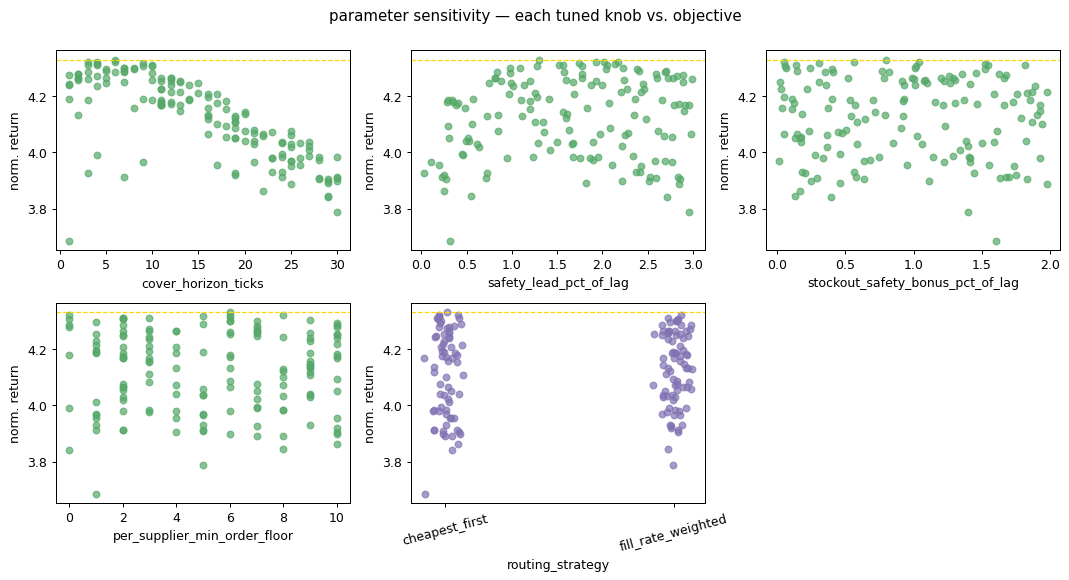

In [6]:
n_panels = len(numeric_params) + len(cat_params)
ncols = 3
nrows = (n_panels + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(12, 3.2 * nrows))
axes = axes.ravel()

y = completed["mean_normalised_return"]
for ax, p in zip(axes, numeric_params):
    ax.scatter(completed[p], y, s=28, color="#55A868", alpha=0.7)
    ax.axhline(best_val, color="gold", ls="--", lw=1)
    ax.set_xlabel(p)
    ax.set_ylabel("norm. return")

for ax, p in zip(axes[len(numeric_params):], cat_params):
    cats = sorted(completed[p].dropna().unique())
    for i, c in enumerate(cats):
        vals = completed.loc[completed[p] == c, "mean_normalised_return"]
        # jitter x so overlapping points are visible
        jitter = np.random.default_rng(0).normal(0, 0.04, size=len(vals))
        ax.scatter(i + jitter, vals, s=28, color="#8172B3", alpha=0.7)
    ax.set_xticks(range(len(cats)))
    ax.set_xticklabels(cats, rotation=15)
    ax.axhline(best_val, color="gold", ls="--", lw=1)
    ax.set_xlabel(p)
    ax.set_ylabel("norm. return")

for ax in axes[n_panels:]:
    ax.axis("off")

fig.suptitle("parameter sensitivity — each tuned knob vs. objective", y=1.0)
plt.tight_layout()
plt.show()

## 5 · Which knobs actually mattered?

A lightweight **importance** proxy, computed straight from `trials.parquet` (no Optuna
re-import needed):

- **numeric** params → magnitude of the Spearman rank correlation with the objective
  (monotonic association, robust to scale and outliers),
- **categorical** params → the spread of group means (best choice − worst choice),
  rescaled onto the same 0–1 axis as the correlations for a rough side-by-side read.

This is a coarser signal than Optuna's fANOVA, but it answers the practical question:
*if I were to fix some knobs and re-search, which ones would I leave free?*

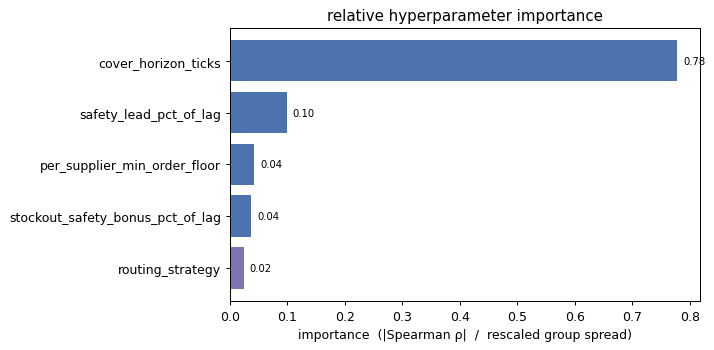

,importance
cover_horizon_ticks,0.778231
safety_lead_pct_of_lag,0.099155
per_supplier_min_order_floor,0.042825
stockout_safety_bonus_pct_of_lag,0.037353
routing_strategy,0.024207


In [7]:
importance = {}
for p in numeric_params:
    rho = completed[p].corr(completed["mean_normalised_return"], method="spearman")
    importance[p] = abs(rho)

for p in cat_params:
    grp = completed.groupby(p)["mean_normalised_return"].mean()
    spread = grp.max() - grp.min()
    # rescale categorical spread against the objective's overall range -> 0..1
    obj_range = completed["mean_normalised_return"].max() - completed["mean_normalised_return"].min()
    importance[p] = spread / obj_range if obj_range else 0.0

imp = pd.Series(importance, name="importance").sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 0.6 * len(imp) + 1))
colors = ["#8172B3" if p in cat_params else "#4C72B0" for p in imp.index]
ax.barh(imp.index, imp.values, color=colors)
ax.set_xlabel("importance  (|Spearman ρ|  /  rescaled group spread)")
ax.set_title("relative hyperparameter importance")
for i, v in enumerate(imp.values):
    ax.text(v + 0.01, i, f"{v:.2f}", va="center", fontsize=8)
plt.tight_layout()
plt.show()

display(imp.sort_values(ascending=False).to_frame())

## 6 · The leaderboard — top trials

The best handful of trials, with their parameters and KPIs side by side. Where the top
rows agree on a parameter, that's a region the search kept returning to; where they
disagree, the objective is flat there (consistent with the sensitivity panels above).

In [8]:
kpi_cols = ["mean_normalised_return", "mean_net_profit", "mean_service_level",
            "mean_stockout_rate", "mean_inventory_turnover"]

leaderboard = (
    completed.sort_values("mean_normalised_return", ascending=False)
    .head(10)
    .set_index("trial_id")[param_cols + kpi_cols]
)
display(leaderboard.style.format({c: "{:.4f}" for c in kpi_cols if c != "mean_net_profit"}
                                 | {"mean_net_profit": "{:,.0f}"}))

,cover_horizon_ticks,safety_lead_pct_of_lag,stockout_safety_bonus_pct_of_lag,per_supplier_min_order_floor,routing_strategy,mean_normalised_return,mean_net_profit,mean_service_level,mean_stockout_rate,mean_inventory_turnover
trial_id,,,,,,,,,,
57,6,1.301555,0.797009,6,cheapest_first,4.3308,"153,886",0.9548,0.0512,391.2989
59,3,1.927258,0.053023,6,cheapest_first,4.3228,"154,078",0.9569,0.0817,455.9330
39,6,2.167356,0.561545,0,cheapest_first,4.3215,"153,987",0.9629,0.0477,399.0703
91,4,2.014720,1.040615,8,fill_rate_weighted,4.3209,"153,808",0.9625,0.0487,443.0769
116,9,1.743715,0.308725,5,cheapest_first,4.3178,"153,645",0.9574,0.0495,359.6757
15,4,2.139734,1.521570,6,cheapest_first,4.3150,"153,771",0.9599,0.0494,415.5186
49,4,1.566730,1.539987,2,cheapest_first,4.3123,"153,542",0.9554,0.0575,470.9616
17,10,1.525712,1.815133,2,fill_rate_weighted,4.3116,"153,374",0.9587,0.0518,346.0610
62,3,2.049020,0.142377,3,cheapest_first,4.3106,"153,516",0.9624,0.0509,467.4525


## 7 · Robustness — variance across seeds

The objective is a **mean over CRN seeds**, but a high mean with high variance is a fragile
winner. `per_seed.parquet` lets us recover the spread each trial saw. Left: every trial as a
(mean, std) point — the ideal winner sits toward the upper-left (high return, low spread).
Right: the actual per-seed return distribution for the winning trial.

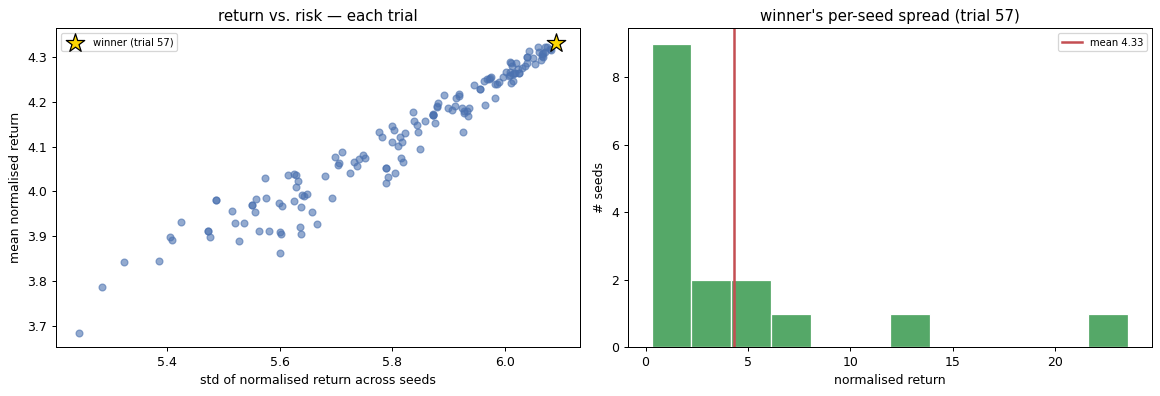

winner trial 57: mean 4.331  std 6.091  (cv 1.41) over 16 seeds


In [9]:
seed_stats = (
    per_seed.groupby("trial_id")["normalised_return"]
    .agg(mean="mean", std="std")
    .reset_index()
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

ax1.scatter(seed_stats["std"], seed_stats["mean"], s=30, color="#4C72B0", alpha=0.6)
win = seed_stats.loc[seed_stats["trial_id"] == best_id].iloc[0]
ax1.scatter([win["std"]], [win["mean"]], s=240, marker="*", color="gold",
            edgecolor="black", zorder=4, label=f"winner (trial {best_id})")
ax1.set_xlabel("std of normalised return across seeds")
ax1.set_ylabel("mean normalised return")
ax1.set_title("return vs. risk — each trial")
ax1.legend(fontsize=8)

win_seeds = per_seed.loc[per_seed["trial_id"] == best_id, "normalised_return"]
ax2.hist(win_seeds, bins=12, color="#55A868", edgecolor="white")
ax2.axvline(win_seeds.mean(), color="#C44E52", lw=2, label=f"mean {win_seeds.mean():.2f}")
ax2.set_xlabel("normalised return")
ax2.set_ylabel("# seeds")
ax2.set_title(f"winner's per-seed spread (trial {best_id})")
ax2.legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f"winner trial {best_id}: mean {win['mean']:.3f}  std {win['std']:.3f}  "
      f"(cv {win['std'] / win['mean']:.2f}) over {len(win_seeds)} seeds")

## 8 · The honest test — holdout confirmation

The winner was chosen on the *search* seeds, so it carries some **winner's-curse** bias.
`confirm_top_k` re-evaluates the top-K trials **and the published default**
(`OrderUpToPolicy()` with no kwargs) on a **disjoint** holdout seed set. The headline is
`tuned_rank_1` (the search winner) vs `default`, paired seed-for-seed (CRN), with a
bootstrap CI on the difference.

If the holdout cell below is skipped, this study was run without `confirm_top_k` — see
notebook 05 §5 for how to produce these artifacts.

In [10]:
if holdout is None:
    print("no holdout.parquet — skipping confirmation (run confirm_top_k to produce it).")
else:
    per_label = (
        holdout.groupby("label")["net_profit"]
        .agg(["mean", "std", "count"])
        .sort_values("mean", ascending=False)
    )
    display(per_label)

    if holdout_summary:
        s = holdout_summary
        print(f"\ntuned_rank_1 mean net profit : {s['tuned_best_mean_net_profit']:,.0f} "
              f"(95% CI [{s['tuned_best_ci_low']:,.0f}, {s['tuned_best_ci_high']:,.0f}])")
        print(f"default      mean net profit : {s['default_mean_net_profit']:,.0f} "
              f"(95% CI [{s['default_ci_low']:,.0f}, {s['default_ci_high']:,.0f}])")
        print(f"headline paired uplift       : {s['headline_uplift']:,.0f} "
              f"(95% CI [{s['headline_uplift_ci_low']:,.0f}, {s['headline_uplift_ci_high']:,.0f}])")
        sign = "above" if s['headline_uplift_ci_low'] > 0 else "spanning"
        print(f"\nThe uplift CI is {sign} zero -> the tuned policy is "
              f"{'a real, significant improvement' if s['headline_uplift_ci_low'] > 0 else 'not clearly better'} "
              f"over the default on held-out seeds.")

,mean,std,count
label,,,
tuned_rank_3,149977.098750,43705.551592,32
tuned_rank_4,149597.619375,43641.113553,32
tuned_rank_1,148961.975312,44341.106679,32
tuned_rank_5,148886.934062,43891.780913,32
tuned_rank_2,148785.076563,44276.313044,32
default,140728.964688,41900.482139,32



tuned_rank_1 mean net profit : 148,962 (95% CI [134,792, 163,890])
default      mean net profit : 140,729 (95% CI [126,763, 156,509])
headline paired uplift       : 8,233 (95% CI [6,239, 10,326])

The uplift CI is above zero -> the tuned policy is a real, significant improvement over the default on held-out seeds.


### Paired per-seed view

The same holdout seeds, tuned vs. default side by side (CRN means the *only* difference is
the policy). The **win rate** — fraction of seeds where tuned beats default — is the most
intuitive read of whether the tuning generalised.

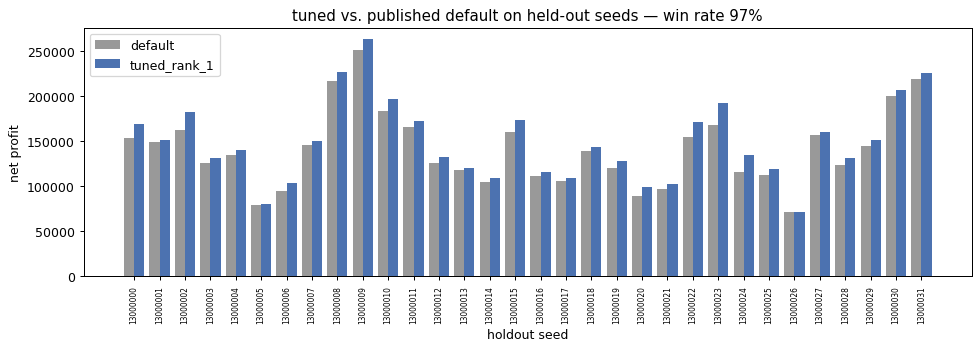

tuned beats default on 31/32 holdout seeds (97%); mean paired uplift 8,233.


In [11]:
if holdout is not None and "tuned_rank_1" in set(holdout["label"]):
    tuned   = holdout[holdout["label"] == "tuned_rank_1"].set_index("seed")["net_profit"]
    default = holdout[holdout["label"] == "default"].set_index("seed")["net_profit"]
    paired = pd.DataFrame({"default": default, "tuned_rank_1": tuned})
    paired["uplift"] = paired["tuned_rank_1"] - paired["default"]
    win_rate = (paired["uplift"] > 0).mean()

    fig, ax = plt.subplots(figsize=(11, 4))
    x = range(len(paired))
    ax.bar([i - 0.2 for i in x], paired["default"], width=0.4, label="default", color="#999999")
    ax.bar([i + 0.2 for i in x], paired["tuned_rank_1"], width=0.4, label="tuned_rank_1", color="#4C72B0")
    ax.set_xticks(list(x))
    ax.set_xticklabels(paired.index, rotation=90, fontsize=6)
    ax.set_xlabel("holdout seed")
    ax.set_ylabel("net profit")
    ax.set_title(f"tuned vs. published default on held-out seeds — win rate {win_rate:.0%}")
    ax.legend()
    plt.tight_layout()
    plt.show()

    print(f"tuned beats default on {(paired['uplift'] > 0).sum()}/{len(paired)} "
          f"holdout seeds ({win_rate:.0%}); mean paired uplift {paired['uplift'].mean():,.0f}.")
else:
    print("no paired holdout labels to compare.")

## Where to next

- Re-point `STUDY_DIR` at any other `runs/tuning/<name>/` to analyze a different study —
  a different policy (`reorder_point`, `periodic_order_up_to`, `periodic_reorder`) brings
  its own `Q` / `review_interval` columns, and this notebook adapts to them automatically.
- Produce a fresh study to analyze here:
  `uv run python -m src.tuning.study --policy order_up_to --trials 150 --study-name my_run`.
- The importance proxy in §5 is deliberately dependency-light. For Optuna's native fANOVA
  importances, keep the in-memory `study` object from a run (notebook 05) and call
  `optuna.importance.get_param_importances(study)`.

| notebook | topic |
|---|---|
| **04** | compare the four textbook policies under Common Random Numbers |
| **05** | tune a policy with Optuna — *how to drive a study* |
| **05a** | analyze a completed study from disk — *this notebook* |